In [1]:
import pandas as pd

df = pd.read_csv('../../fact-dropbox/single_ion_conductivity/Boron8-formatted.csv')
df

,Molecule,Energy_Barrier(kJ/mol),Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site11
0,B1,46.897249,-502.148490,-506.568821,-505.902701,-505.393205,-520.618490,NaN,NaN,NaN,NaN,NaN,NaN
1,B2,53.551874,-505.823927,-509.347216,-505.998850,-506.006108,-521.599899,NaN,NaN,NaN,NaN,NaN,NaN
2,B3,51.550183,-520.033097,-520.749525,-521.222319,-301.299958,-521.842849,NaN,NaN,NaN,NaN,NaN,NaN
3,B4,41.171788,-459.116705,-483.058349,-476.336862,-257.502707,-291.332924,NaN,NaN,NaN,NaN,NaN,NaN
4,B5,39.510929,-442.022866,-432.023337,-432.076961,-493.812942,-492.810357,NaN,NaN,NaN,NaN,NaN,NaN
5,B6,40.497195,-464.487616,-482.177816,-463.296407,-302.748002,-301.773116,-289.359861,-292.129911,-308.437811,-301.634199,NaN,NaN
6,B7,32.062152,-494.986119,-497.427656,-494.727470,-303.923899,-518.416589,-322.719366,-209.698090,-187.237916,-311.826105,-206.797079,-185.728119
7,B8,30.449807,-481.174108,-480.959538,-481.818356,-279.414799,-541.091154,-291.423425,-204.282805,-173.180037,NaN,NaN,NaN


In [202]:
import numpy as np
from sklearn import preprocessing
import torch

target_key = 'Energy_Barrier(kJ/mol)'

# x = np.nanmean(df.loc[:, 'Site1':'Site11'], axis=1).reshape(-1, 1)

f = df.loc[:, []]# .fillna(0)
f['SiteAvg'] = np.nanmean(df.loc[:, 'Site1':'Site11'], axis=1)
# f['NSites'] = np.sum(np.isfinite(df.loc[:, 'Site1':'Site11']), axis=1)
f['MinE'] = np.nanmin(df.loc[:, 'Site1':'Site11'], axis=1)
# f['MaxE'] = np.nanmax(df.loc[:, 'Site1':'Site11'], axis=1)
# f['MedE'] = np.nanmedian(df.loc[:, 'Site1':'Site11'], axis=1)

# f['SiteAvg13'] = np.nanmean(df.loc[:, 'Site1':'Site5'])
# f['Site123'] = np.nanmedian(df.loc[:, 'Site1':'Site3'])

# f['Site45'] = np.nanmean(df.loc[:, 'Site4':'Site5'])
# mu = np.nanmean(df.loc[:, 'Site1':])
# f['Site6+'] = np.nanmean(df.loc[:, 'Site6':].fillna(0))

s = preprocessing.StandardScaler()
x = s.fit_transform(f)

y = df.loc[:, target_key].values.reshape(-1, 1)

train_idx = np.array([1, 3, 5, 6, 8])-1
valid_idx = np.array([2, 4, 7])-1

x_train = torch.tensor(x[train_idx]).float()
y_train = torch.tensor(y[train_idx]).float()

x_valid = torch.tensor(x[valid_idx]).float()
y_valid = torch.tensor(y[valid_idx]).float()

In [470]:
target_key = 'Energy_Barrier(kJ/mol)'

f = df.loc[:, ['Site2']]#.fillna(0)
f['SiteAvg'] = np.nanmean(df.loc[:, 'Site1':'Site11'], axis=1)
f['MinE'] = np.nanmin(df.loc[:, 'Site1':'Site11'], axis=1)

# f = f.loc[:, ['SiteAvg']]

x = f.values
y = df.loc[:, target_key].values.reshape(-1, 1)

train_idx = np.array([1, 3, 5, 6, 8])-1
valid_idx = np.array([2, 4, 7])-1

x_train = torch.tensor(x[train_idx]).float()
y_train = torch.tensor(y[train_idx]).float()

x_valid = torch.tensor(x[valid_idx]).float()
y_valid = torch.tensor(y[valid_idx]).float()

In [547]:
from torch import nn, optim
import sparsenn
from sparsenn import pareto

input_dim = x_train.shape[1]
hidden_dim = (4, )
output_dim = y_train.shape[1]

model = sparsenn.RegularizedMLP(input_dim, hidden_dim, output_dim, activation=nn.LeakyReLU())
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-2)

In [548]:
lmbda_reg = 1e-3
model.train()
for epoch in range(int(1e4)):
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    reg_loss = model.regularization_loss()
    total_loss = loss + lmbda_reg * reg_loss
    total_loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        with torch.no_grad():
            outputs = model(x_valid)
            valid_loss = criterion(outputs, y_valid)
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}')

Epoch 100, MSE: 267.4993, L0R: 13.55, ValMSE: 26.8117
Epoch 200, MSE: 130.6138, L0R: 13.81, ValMSE: 43.0024
Epoch 300, MSE: 31.8729, L0R: 13.84, ValMSE: 96.7794
Epoch 400, MSE: 396.4594, L0R: 13.92, ValMSE: 118.7090
Epoch 500, MSE: 30.0885, L0R: 13.96, ValMSE: 42.8662
Epoch 600, MSE: 33.4805, L0R: 13.97, ValMSE: 42.0214
Epoch 700, MSE: 72.3301, L0R: 13.99, ValMSE: 41.1511
Epoch 800, MSE: 133.7422, L0R: 14.00, ValMSE: 37.3742
Epoch 900, MSE: 33.8161, L0R: 14.02, ValMSE: 42.3684
Epoch 1000, MSE: 28.2039, L0R: 14.02, ValMSE: 32.4657
Epoch 1100, MSE: 28.3689, L0R: 14.03, ValMSE: 35.9705
Epoch 1200, MSE: 27.7100, L0R: 14.02, ValMSE: 89.2703
Epoch 1300, MSE: 25.6299, L0R: 14.03, ValMSE: 30.9489
Epoch 1400, MSE: 141.8886, L0R: 14.03, ValMSE: 28.7567
Epoch 1500, MSE: 25.6361, L0R: 14.03, ValMSE: 28.7981
Epoch 1600, MSE: 24.1639, L0R: 14.03, ValMSE: 30.6391
Epoch 1700, MSE: 24.2804, L0R: 14.03, ValMSE: 23.5568
Epoch 1800, MSE: 131.6400, L0R: 14.03, ValMSE: 23.6999
Epoch 1900, MSE: 21.7439, L0R:

['input_0', 'input_1', 'input_2', 'hidden1_0', 'hidden1_1', 'hidden1_2', 'hidden1_3', 'output_0']


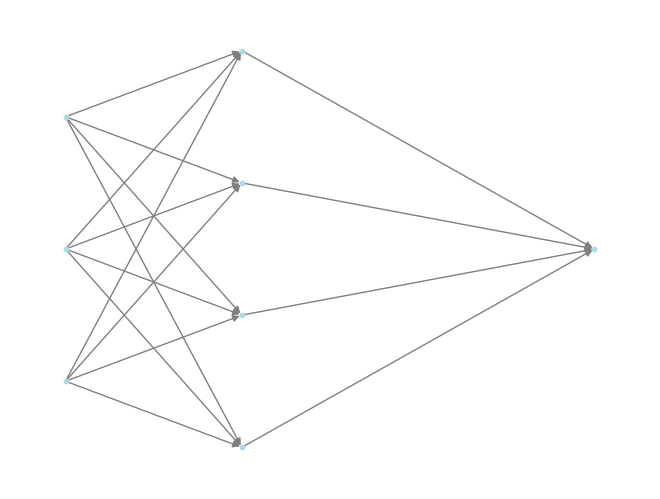

In [549]:
from sparsenn import viz

# Render the optimized architecture 
g = viz.gated_connections_graph(model) 
fig = viz.render_sparse_nn(g)
print(g.nodes)

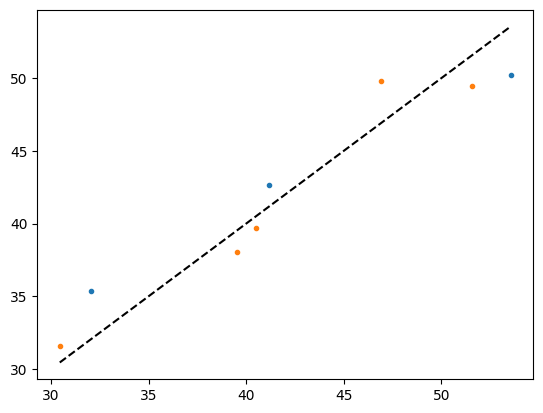

In [540]:
import matplotlib.pyplot as plt

with torch.no_grad():
    y_hat = model(x_valid)
plt.plot(y_valid, y_hat, '.')
with torch.no_grad():
    y_hat = model(x_train)
plt.plot(y_train, y_hat, '.')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')

In [550]:
from copy import deepcopy
from sklearn import model_selection

input_dim = x_train.shape[1]
hidden_dim = (4, )
output_dim = y_train.shape[1]
criterion = nn.MSELoss()

fold_models = []

folds = model_selection.LeaveOneOut()
pred = np.zeros_like(y)
for i, (train_index, test_index) in enumerate(folds.split(x)):
    # set training data
    x_train = torch.tensor(x[train_idx]).float()
    y_train = torch.tensor(y[train_idx]).float()
    x_valid = torch.tensor(x[test_index]).float()
    y_valid = torch.tensor(y[test_index]).float()
    # create model
    model = sparsenn.RegularizedMLP(input_dim, hidden_dim, output_dim, activation=nn.LeakyReLU())
    optimizer = optim.Adam(model.parameters(), lr=2e-2)
    # train model
    lmbda_reg = 1e-3
    model.train()
    for epoch in range(int(1e4)):
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        reg_loss = model.regularization_loss()
        total_loss = loss + lmbda_reg * reg_loss
        total_loss.backward()
        optimizer.step()
    
        if (epoch+1) % 1000 == 0:
            with torch.no_grad():
                outputs = model(x_valid)
                valid_loss = criterion(outputs, y_valid)
            print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}')
    # record prediction
    with torch.no_grad():
        pred[i] = model(x_valid).tolist()[0]
    fold_models.append(deepcopy(model))
r2 = 1 - np.var(pred - y) / np.var(y)
print(f'R2 (test) = {r2:.3f}')
mae = np.mean(np.abs(pred - y))
print(f'MAE (test) = {mae:.3f}')

Epoch 1000, MSE: 24.5385, L0R: 14.17, ValMSE: 0.0211
Epoch 2000, MSE: 20.9457, L0R: 14.18, ValMSE: 5.1839
Epoch 3000, MSE: 17.3340, L0R: 14.19, ValMSE: 0.2493
Epoch 4000, MSE: 14.3276, L0R: 14.21, ValMSE: 1.8126
Epoch 5000, MSE: 6.6723, L0R: 14.21, ValMSE: 6.3696
Epoch 6000, MSE: 3.9262, L0R: 14.21, ValMSE: 8.2688
Epoch 7000, MSE: 5.3947, L0R: 14.21, ValMSE: 2.9509
Epoch 8000, MSE: 488.7025, L0R: 13.44, ValMSE: 6790.0254
Epoch 9000, MSE: 5.5531, L0R: 14.22, ValMSE: 9.8825
Epoch 10000, MSE: 5.2290, L0R: 14.23, ValMSE: 6.1080
Epoch 1000, MSE: 42.2528, L0R: 14.01, ValMSE: 1.5501
Epoch 2000, MSE: 25.8573, L0R: 14.09, ValMSE: 271.2725
Epoch 3000, MSE: 22.9683, L0R: 14.10, ValMSE: 27.8459
Epoch 4000, MSE: 27.3442, L0R: 14.11, ValMSE: 36.5958
Epoch 5000, MSE: 22.1141, L0R: 14.13, ValMSE: 39.9614
Epoch 6000, MSE: 23.8176, L0R: 14.15, ValMSE: 6.2361
Epoch 7000, MSE: 9.6184, L0R: 14.14, ValMSE: 15.7913
Epoch 8000, MSE: 7.4024, L0R: 14.14, ValMSE: 13.1179
Epoch 9000, MSE: 4.2791, L0R: 14.09, ValM

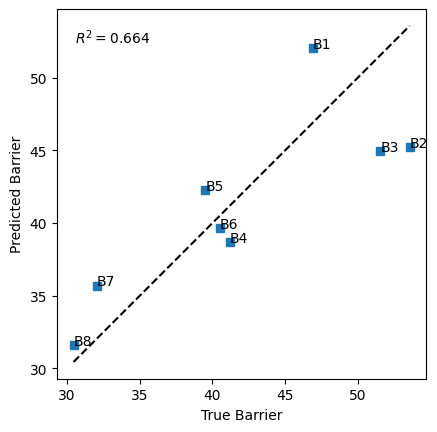

In [551]:
# for i, model in enumerate(fold_models):
#     with torch.no_grad():
#         pred = model(torch.tensor(x).float())
#     _ = plt.plot(y, pred, '.')
_ = plt.plot(y, pred, 's')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('True Barrier')
plt.ylabel('Predicted Barrier')
ax = plt.gca()
ax.text(0.05, 0.95, f'$R^2 = {r2:.3f}$', transform=ax.transAxes, va='top')
ax.set_aspect('equal')
for i, idx in enumerate(df.index):
    ax.text(y[idx], pred[i], df.loc[idx, 'Molecule'])

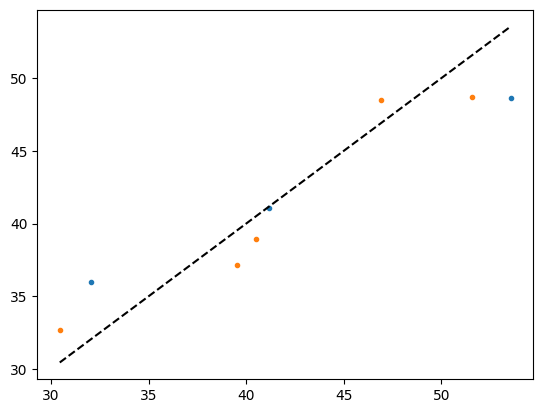

In [323]:
import matplotlib.pyplot as plt

with torch.no_grad():
    y_hat = model(x_valid)
plt.plot(y_valid, y_hat, '.')
with torch.no_grad():
    y_hat = model(x_train)
plt.plot(y_train, y_hat, '.')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')

In [107]:
# def train_optimal(model):

explored_values = []
frontier = []

max_epochs = int(1e5)

for k in range(1):
    lmbda_reg = 1e-5 * 2**k
    reg_prec = 3
    patience_interval = 1000
    last_best = 0
    model.train()
    for epoch in range(max_epochs):
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        reg_loss = model.regularization_loss()
        total_loss = loss + lmbda_reg * reg_loss
        total_loss.backward()
        optimizer.step()
    
        point = np.array([loss.item(), np.round(reg_loss.item(), reg_prec)])
        explored_values.append(point)
        if not pareto.is_dominated(point, frontier):
            frontier = pareto.update_pareto_front(point, frontier)
            last_best = epoch
    
        if reg_loss.item() < 1:
            break
    
        if (epoch+1) % 1000 == 0:
            with torch.no_grad():
                outputs = model(x_valid)
                valid_loss = criterion(outputs, y_valid)
            print(f'Epoch {epoch+1}, Lambda {lmbda_reg:.3e}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}')
            
        if epoch - last_best > patience_interval:
            print('Patience expired...')
            break
            
    # return explored_values, frontier

Epoch 1000, Lambda 1.000e-05, MSE: 0.1365, L0R: 144.75, ValMSE: 20.2864
Epoch 2000, Lambda 1.000e-05, MSE: 0.4031, L0R: 142.15, ValMSE: 22.1704
Epoch 3000, Lambda 1.000e-05, MSE: 0.1662, L0R: 139.85, ValMSE: 19.2966
Epoch 4000, Lambda 1.000e-05, MSE: 0.0229, L0R: 136.75, ValMSE: 17.4015
Epoch 5000, Lambda 1.000e-05, MSE: 0.3447, L0R: 132.97, ValMSE: 20.9217
Epoch 6000, Lambda 1.000e-05, MSE: 0.0353, L0R: 130.70, ValMSE: 20.7308
Epoch 7000, Lambda 1.000e-05, MSE: 0.0070, L0R: 129.14, ValMSE: 18.8656
Epoch 8000, Lambda 1.000e-05, MSE: 0.0726, L0R: 127.37, ValMSE: 17.7530
Epoch 9000, Lambda 1.000e-05, MSE: 0.0063, L0R: 120.70, ValMSE: 27.4376
Epoch 10000, Lambda 1.000e-05, MSE: 0.0031, L0R: 119.16, ValMSE: 28.1216
Epoch 11000, Lambda 1.000e-05, MSE: 0.0002, L0R: 117.67, ValMSE: 28.1916
Epoch 12000, Lambda 1.000e-05, MSE: 0.1638, L0R: 114.17, ValMSE: 32.3674
Epoch 13000, Lambda 1.000e-05, MSE: 0.0002, L0R: 113.06, ValMSE: 36.3622
Epoch 14000, Lambda 1.000e-05, MSE: 0.0003, L0R: 111.50, Val

Text(0, 0.5, 'Parameters')

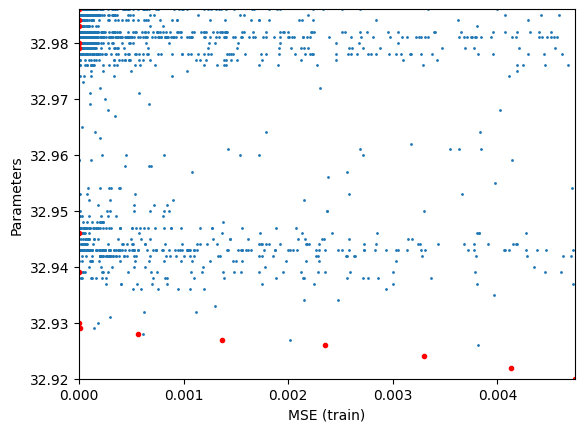

In [96]:
from matplotlib import pyplot as plt

v = np.array(explored_values)
p = np.array(frontier)
# p = is_pareto_efficient(v, return_mask=True)
plt.scatter(*v.T, s=1, rasterized=True) # c=np.arange(v.shape[0]), 
plt.plot(p[:, 0], p[:, 1], 'r.')
plt.xlim(p[:, 0].min(), p[:, 0].max())
plt.ylim(p[:, 1].min(), p[:, 1].max())
plt.xlabel('MSE (train)')
plt.ylabel('Parameters')

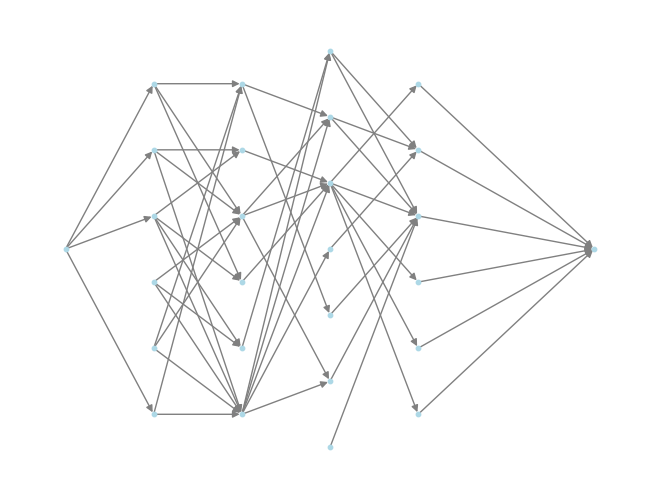

In [119]:
from sparsenn import viz

# Render the optimized architecture 
g = viz.gated_connections_graph(model) 
fig = viz.render_sparse_nn(g)

In [74]:
model.eval()
gated_weights = [
    module.weight * torch.clamp(torch.sigmoid(module.log_alpha) * (module.zeta - module.gamma) + module.gamma, 0, 1)
    for module in model.layers if isinstance(module, sparsenn.L0Linear)
]
np.argwhere(gated_weights[0].detach().numpy() > 1e-6)

array([[ 2,  0],
       [ 2, 12],
       [ 3,  0],
       [ 3,  1],
       [ 6,  3],
       [ 6,  6],
       [ 6,  7],
       [ 7,  0],
       [ 7,  1],
       [ 7, 12]])

In [85]:
g.nodes()

NodeView(('input_0', 'hidden1_0', 'hidden1_1', 'hidden1_3', 'hidden1_5', 'hidden1_6', 'hidden1_7', 'hidden2_0', 'hidden2_1', 'hidden2_2', 'hidden2_3', 'hidden2_4', 'hidden2_5', 'hidden2_6', 'hidden2_7', 'output_0'))